In [1]:
import pandas as pd

In [2]:
yr = pd.read_csv("C:\\Users\\PC-NITRO\\2nd Semester\\Data Visualization\\New folder\\netflix_.csv")

In [3]:
yr.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
yr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
yr.shape

(8807, 12)

In [6]:
yr.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
yr.duplicated().sum()

0

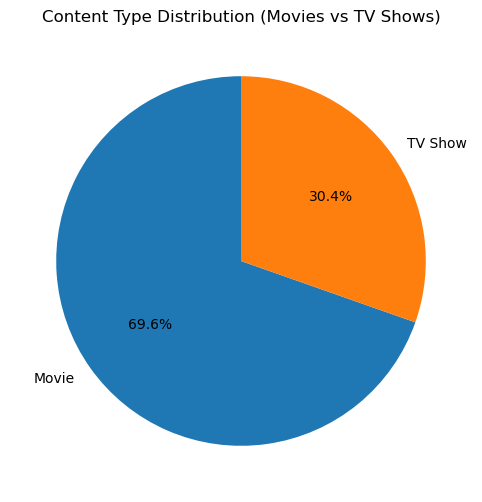

In [8]:
import matplotlib.pyplot as plt

# Count the number of Movies and TV Shows
content_type_counts = yr['type'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 6))
plt.pie(content_type_counts, labels=content_type_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Content Type Distribution (Movies vs TV Shows)')
plt.show()
#Shows the percentage split between Movies and TV Shows available on Netflix.

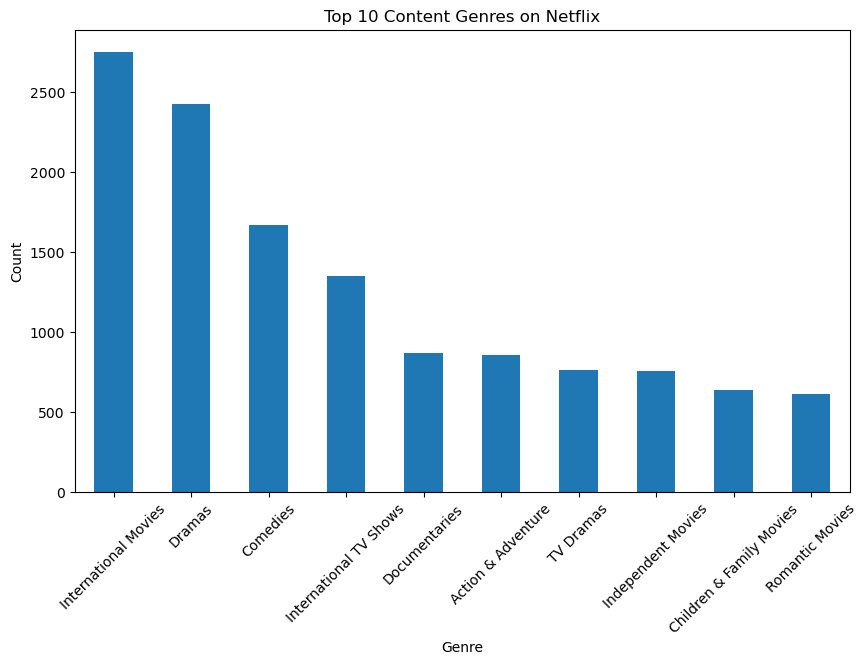

In [9]:
from collections import Counter

# Split and count genres from the 'listed_in' column
genres = yr['listed_in'].str.split(', ').explode()
genre_counts = genres.value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(10, 6))
genre_counts.plot(kind='bar')
plt.title('Top 10 Content Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
#Displays the most common genres on Netflix based on how many titles fall under each category.

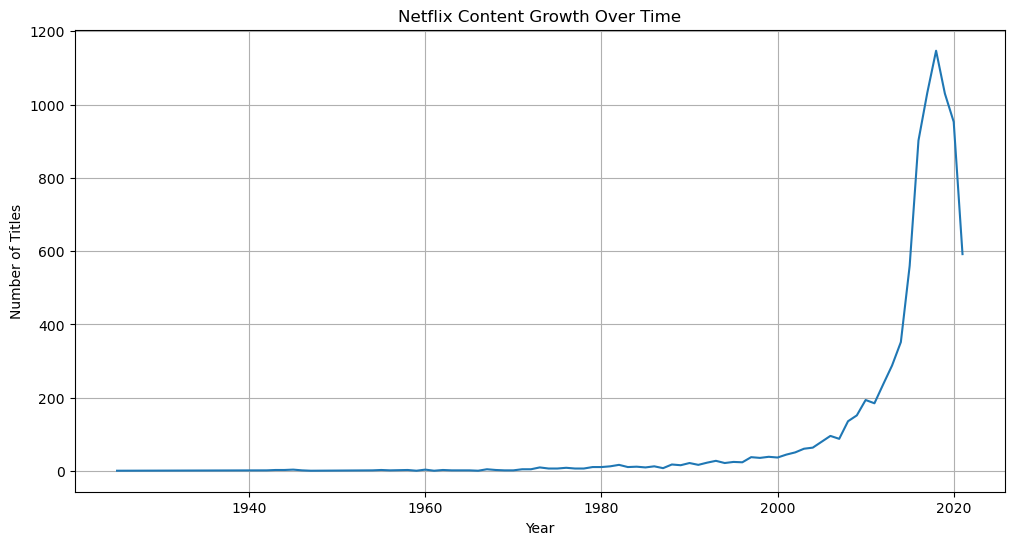

In [10]:
# Extract the release year and count content per year
content_by_year = yr['release_year'].value_counts().sort_index()

# Create a line plot
plt.figure(figsize=(12, 6))
content_by_year.plot(kind='line')
plt.title('Netflix Content Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()
# Shows how the number of titles released each year has changed over time on Netflix.

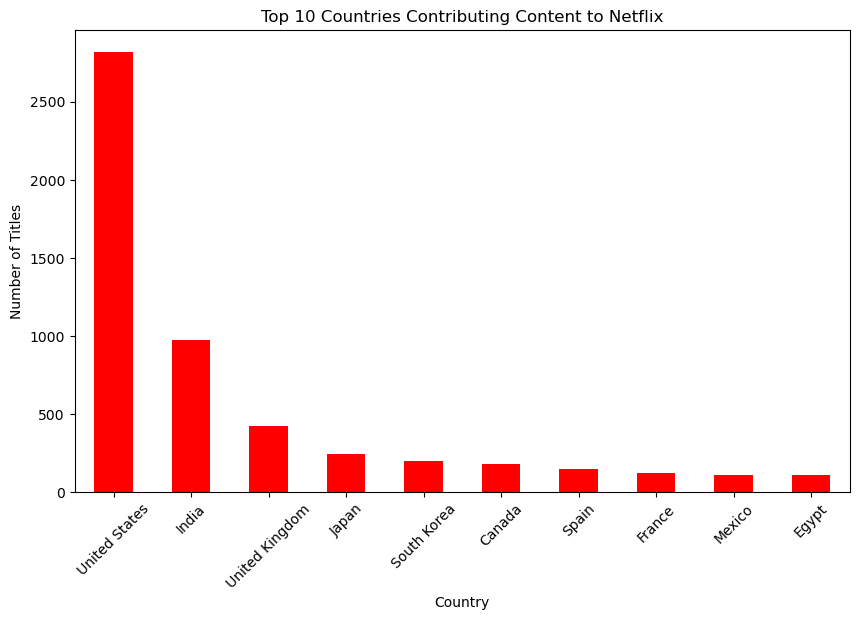

In [11]:
# Count the top 10 countries by number of titles
top_countries = yr['country'].value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='red')
plt.title('Top 10 Countries Contributing Content to Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()
# Highlights which countries produce the most content available on Netflix.

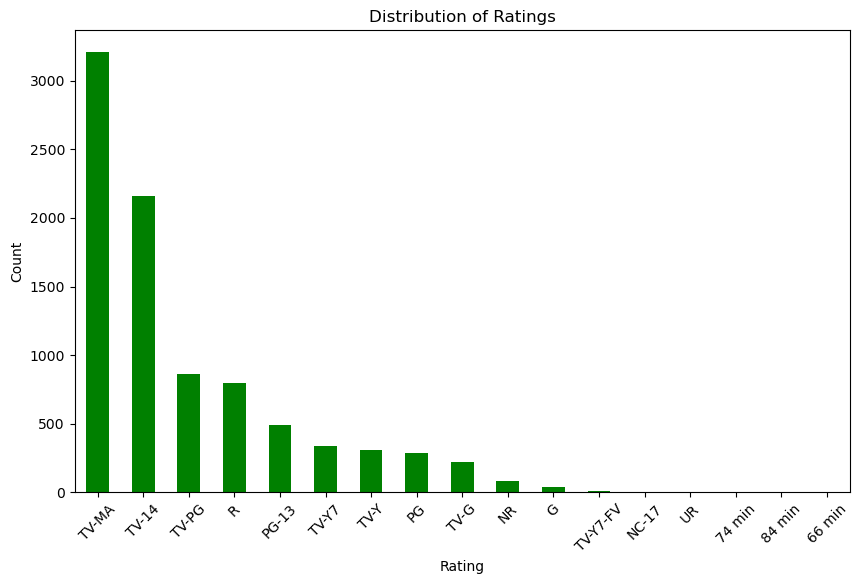

In [12]:
# Count the ratings
ratings_count = yr['rating'].value_counts()

# Create a bar plot
plt.figure(figsize=(10, 6))
ratings_count.plot(kind='bar', color='green')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
#  Shows how Netflix titles are spread across different content ratings like TV-MA, PG-13, etc.

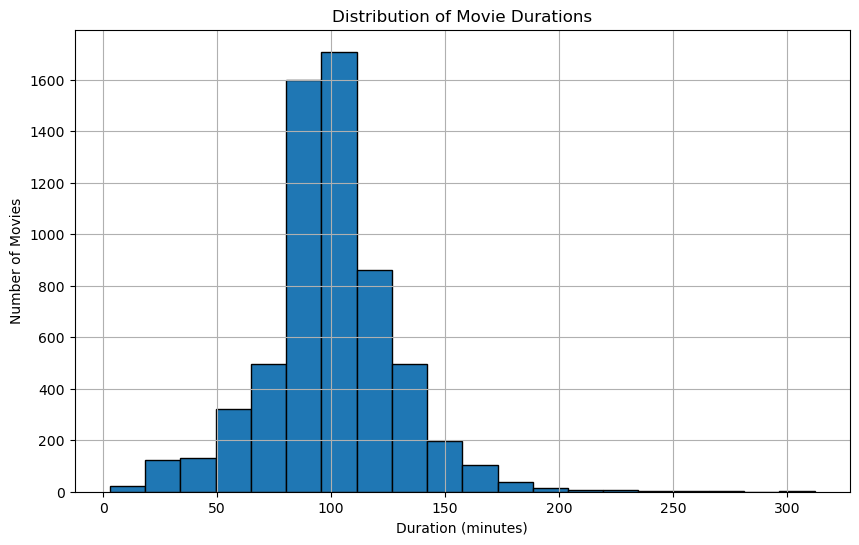

In [13]:
# Parse duration value first (if not done already)
yr['duration_value'] = yr['duration'].str.extract(r'(\d+)').astype(float)

# Filter for Movies and extract duration in minutes
movie_durations = yr[yr['type'] == 'Movie']['duration_value'] 

# Create a histogram
plt.figure(figsize=(10, 6))
plt.hist(movie_durations, bins=20, edgecolor='black')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show()
# Shows how long most Netflix movies are, revealing the most common runtime in minutes.

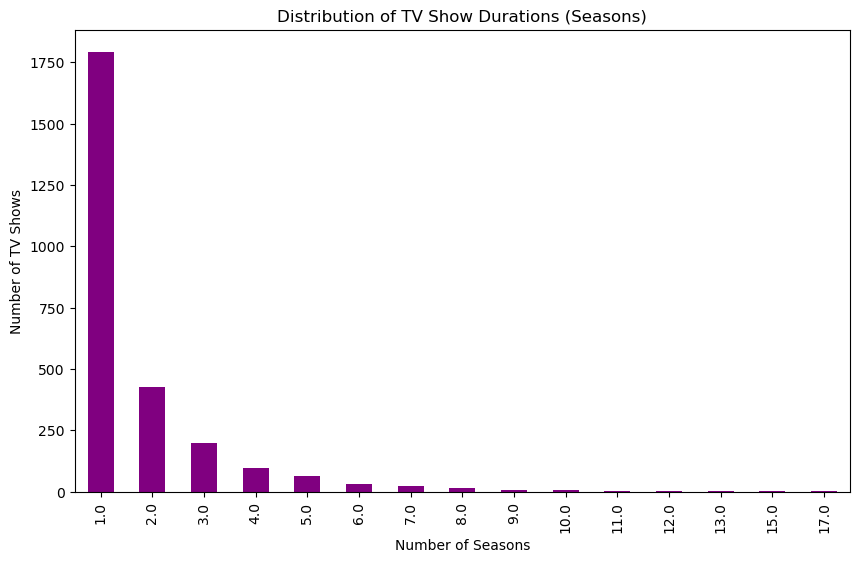

In [14]:
# Filter for TV Shows and extract seasons
tv_durations = yr[yr['type'] == 'TV Show']['duration_value']

# Create a bar plot
plt.figure(figsize=(10, 6))
tv_durations.value_counts().sort_index().plot(kind='bar', color='purple')
plt.title('Distribution of TV Show Durations (Seasons)')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.show()
# Shows how many seasons most Netflix TV shows have, indicating whether short or long series are more common.

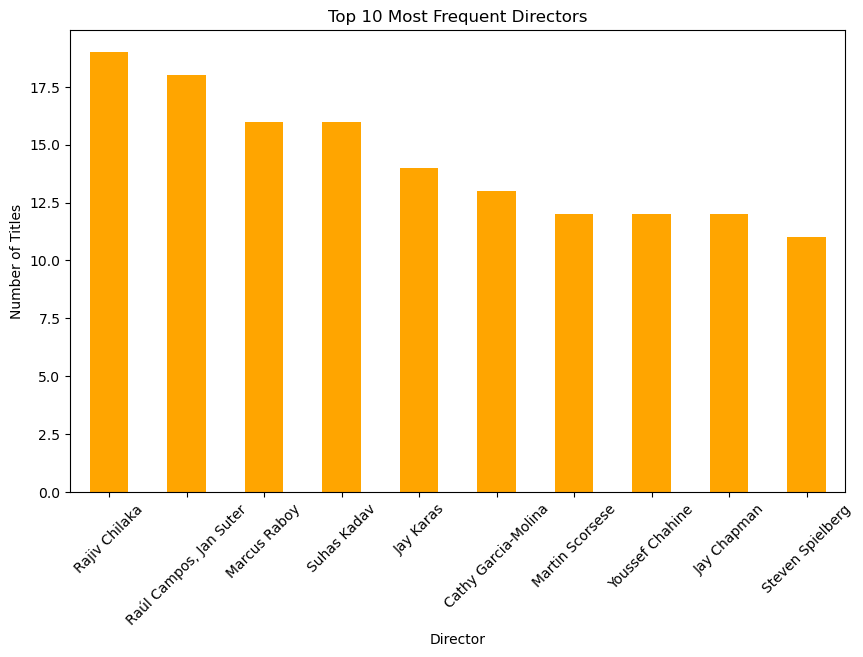

In [15]:
# Count the top 10 directors
top_directors = yr['director'].value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(10, 6))
top_directors.plot(kind='bar', color='orange')
plt.title('Top 10 Most Frequent Directors')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()
# Identifies the directors who have the highest number of titles on Netflix.

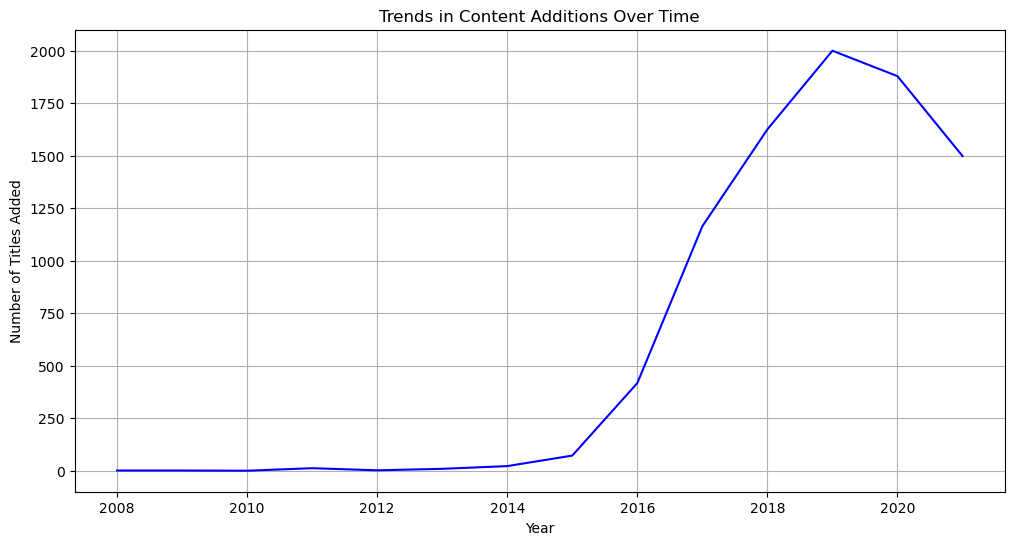

In [16]:
# Convert 'date_added' to datetime format (if not already done)
yr['date_added'] = pd.to_datetime(yr['date_added'], errors='coerce')

# Extract the year from 'date_added'
yr['added_year'] = yr['date_added'].dt.year

# Count the number of titles added per year and sort by year
content_added_by_year = yr['added_year'].value_counts().sort_index()

# Create a line plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
content_added_by_year.plot(kind='line', color='blue')
plt.title('Trends in Content Additions Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)
plt.show()
# Shows how many new titles Netflix added each year, reflecting the platform's growth strategy.

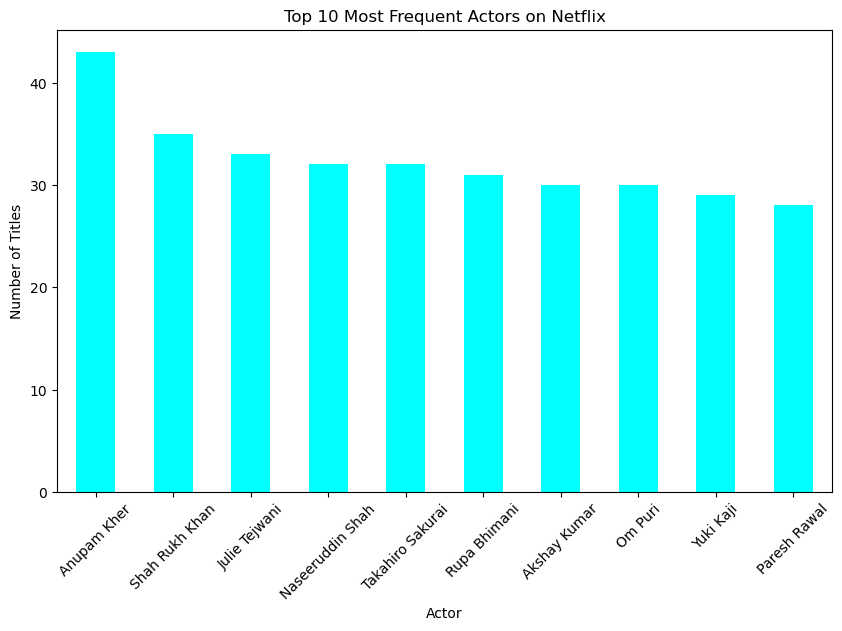

In [17]:
# Split and count actors from the 'cast' column
actors = yr['cast'].str.split(', ').explode()
top_actors = actors.value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(10, 6))
top_actors.plot(kind='bar', color='cyan')
plt.title('Top 10 Most Frequent Actors on Netflix')
plt.xlabel('Actor')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()
# Reveals the actors who appear most frequently across Netflix's entire content library.